# Gaussian noise robustness — dense models and the ZCF baseline on identical corrupted data

Frank specified noise on the **inductance values**. That settles a stage the methodology
document deliberately left open: the noise goes on L₂ and L₃ *before* the differential is
formed, not onto the finished 16-feature vector. The two are not equivalent — forming
ΔL = L₂ − L₃ transforms the noise, and does so very unevenly across the spectrum.

The comparison against the ZCF baseline only means something if both methods see the same
corrupted data, so this notebook perturbs **once**, at the raw coil level, and feeds the
identical frame down both paths. Nothing is retrained; the estimators are loaded from
`models/`.

**Noise model.** For each coil c ∈ {2,3} and frequency f:

$$\sigma_{c,f} = \text{level} \times |L_c(f)| = \text{level}\times\sqrt{\Re L_c(f)^2 + \Im L_c(f)^2}$$

with four independent draws per frequency (real and imaginary, per coil). The scale is the
coil's complex **modulus** rather than each value's own magnitude, because `H_real` passes
through zero mid-band: a per-value scale would leave the zero crossing almost noise-free,
which is exactly where the ZCF baseline is most fragile, and would flatter it.

In [23]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Poly2+Ridge fits mu_r in log space, and under noise its linear extrapolation runs far
# enough that exp() overflows to inf. That is a real result about the model, reported as
# 'overflow' in the tables below and counted -- the warning itself is just noise here.
warnings.filterwarnings('ignore', message='overflow encountered in exp')
warnings.filterwarnings('ignore', message='invalid value encountered in subtract')

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

fig_dir = project_root / 'figures' / 'robustness'; fig_dir.mkdir(parents=True, exist_ok=True)
res_dir = project_root / 'results';                res_dir.mkdir(exist_ok=True)

from src.data import load_raw, rename_columns, compute_differential
from src.robustness import (perturb_inductance, to_wide_features, zcf_table,
                            predict_mu_given_rho, predict_rho_given_mu, COIL_COLS)

MODEL_DIR = project_root / 'models'
FINAL = joblib.load(MODEL_DIR / 'final_models.joblib')
SPEC  = joblib.load(MODEL_DIR / 'feature_spec.joblib')
H, SELECTED = SPEC['H'], SPEC['selected']
MODELS = sorted({n for _, n in FINAL})

# --- the two inputs, both clean -------------------------------------------------
# FE test spectra: what gets perturbed. Dense grid: the ZCF calibration, never perturbed
# (it stands in for a lookup table built offline, exactly as in 01_zcf.ipynb).
fe_long    = rename_columns(load_raw('test.xlsx'))
dense_long = compute_differential(rename_columns(load_raw('train.xlsx')))

CALIB = zcf_table(dense_long)
RHOS  = np.sort(CALIB['resistivity'].unique())

TRUTH = (to_wide_features(fe_long, ['permeability', 'resistivity'], H)
         [['permeability', 'resistivity']].reset_index(drop=True))

print(f'FE test    : {fe_long.shape} long -> {len(TRUTH)} materials')
print(f'calibration: {len(CALIB)} dense materials, {CALIB.z.notna().sum()} with a crossing')
print(f'models     : {MODELS}  | selected {SELECTED}')

FE test    : (440, 7) long -> 55 materials
calibration: 225 dense materials, 225 with a crossing
models     : ['GPR (Matern 1.5)', 'GPR (Matern 2.5)', 'Poly2+Ridge', 'kNN (PCA-4)']  | selected GPR (Matern 2.5)


## 1 — What the differential does to the noise

This has to come first, because it decides how the MAPE numbers are read. ΔL is a
difference of two large, similar numbers, so its magnitude varies over the spectrum by
orders of magnitude while |L| barely moves. Since |ΔL| never exceeds |L|, the noise added
to L is **always amplified** in the differential — but by wildly different factors
depending on where in the spectrum it lands:

$$\sigma_{H} = \sqrt{\sigma_{2}^2 + \sigma_{3}^2}, \qquad
\text{effective relative noise} = \sigma_H / |H|$$

Below, at a 1% level, pooled across the 55 FE materials (median). The worst and mildest
channels are located in the table by the code rather than named in prose, so the labels
cannot drift from the numbers.

In [24]:
REF_LEVEL = 0.01

_d = fe_long.copy()
_d['A2'] = np.hypot(_d.coil2_real, _d.coil2_imag)
_d['A3'] = np.hypot(_d.coil3_real, _d.coil3_imag)
_d['sigma_H'] = REF_LEVEL * np.hypot(_d.A2, _d.A3)
_d['H_real'] = _d.coil2_real - _d.coil3_real
_d['H_imag'] = _d.coil2_imag - _d.coil3_imag

amp = []
for f, g in _d.groupby('frequency'):
    for comp in ('H_real', 'H_imag'):
        amp.append(dict(frequency=int(f), component=comp,
                        median_abs_H=np.median(g[comp].abs()),
                        median_abs_L=np.median(np.hypot(g.A2, g.A3)),
                        eff_rel_noise_pct=np.median(g.sigma_H / g[comp].abs()) * 100))
_amp = pd.DataFrame(amp)
AMP  = _amp.pivot(index='frequency', columns='component', values='eff_rel_noise_pct')
MAGH = _amp.pivot(index='frequency', columns='component', values='median_abs_H')

# The extremes are LOCATED in the table, never typed. The previous version of this cell
# named the worst channel "H_real near the zero crossing" and the mildest "H_imag at low
# frequency". Both were wrong -- they are H_imag and H_real at 48 kHz respectively -- and
# it also claimed the noise was "attenuated, not amplified" somewhere, which never happens:
# |dL| never exceeds |L|, so every one of the 16 channels is amplified. The numbers were
# right and only the labels were wrong, which is exactly the failure reading them off the
# data prevents.
_st = AMP.stack()
(f_hi, c_hi), v_hi = _st.idxmax(), _st.max()
(f_lo, c_lo), v_lo = _st.idxmin(), _st.min()
(f_2nd, c_2nd) = _st.sort_values(ascending=False).index[1]

show = AMP.copy()
show.columns = [f'{c}  eff. noise %' for c in AMP.columns]
print(f'Effective relative noise in the differential, at a {REF_LEVEL:.0%} level on L '
      f'(median over {len(TRUTH)} materials):\n')
display(show.style.format('{:,.1f}%'))

print('A 1% noise level on the inductances is NOT a 1% noise level in the feature vector.')
print(f'  worst   : {v_hi:,.0f}%  -- {c_hi} at {f_hi:,} Hz. This is the smallest differential')
print(f'            in the set: median |{c_hi}| = {MAGH.loc[f_hi, c_hi]:.2e} against '
      f'|L| ~ {_amp.median_abs_L.median():.0e}.')
print(f'  next    : {_st[(f_2nd, c_2nd)]:,.0f}%  -- {c_2nd} at {f_2nd:,} Hz, median '
      f'|{c_2nd}| = {MAGH.loc[f_2nd, c_2nd]:.2e}.')
print( '            A second and distinct mechanism: this is the band the ZCF zero crossing')
print( '            lies in, where H_real changes sign and so passes through zero.')
print(f'  mildest : {v_lo:,.1f}%  -- {c_lo} at {f_lo:,} Hz')

print(f'\nNothing is attenuated. Every one of the {AMP.size} channels sits above the '
      f'{REF_LEVEL:.0%} applied to L,')
print(f'because |dL| never exceeds |L|: minimum amplification {v_lo / (REF_LEVEL * 100):.1f}x, '
      f'maximum {v_hi / (REF_LEVEL * 100):,.0f}x,')
print(f'a spread of {v_hi / v_lo:,.0f}x across the {AMP.size} channels.')
print('\nThat spread is the reason a single "noise level" cannot be read as a single SNR,')
print('and why the ZCF baseline degrades on a different curve from the amplitude-based')
print('models: they weight those channels completely differently.')

Effective relative noise in the differential, at a 1% level on L (median over 55 materials):



,H_imag eff. noise %,H_real eff. noise %
frequency,,
375,8.7%,19.5%
750,4.9%,49.4%
1500,3.7%,5.2%
3000,4.6%,2.6%
6000,8.7%,2.1%
12000,19.5%,2.0%
24000,39.5%,1.8%
48000,303.8%,1.6%


A 1% noise level on the inductances is NOT a 1% noise level in the feature vector.
  worst   : 304%  -- H_imag at 48,000 Hz. This is the smallest differential
            in the set: median |H_imag| = 1.90e-06 against |L| ~ 7e-04.
  next    : 49%  -- H_real at 750 Hz, median |H_real| = 1.79e-05.
            A second and distinct mechanism: this is the band the ZCF zero crossing
            lies in, where H_real changes sign and so passes through zero.
  mildest : 1.6%  -- H_real at 48,000 Hz

Nothing is attenuated. Every one of the 16 channels sits above the 1% applied to L,
because |dL| never exceeds |L|: minimum amplification 1.6x, maximum 304x,
a spread of 185x across the 16 channels.

That spread is the reason a single "noise level" cannot be read as a single SNR,
and why the ZCF baseline degrades on a different curve from the amplitude-based
models: they weight those channels completely differently.


## 2 — Protocol

One perturbation per (level, seed); two consumers.

```
pert = perturb_inductance(fe_long, level, seed)        <- ONE call, raw coil level
  |
  +-- dense : to_wide_features(...) -> model.predict(raw 16-col frame)
  |           (the training scaler lives inside each pipeline; no pre-scaling)
  |
  +-- ZCF   : compute_differential(...) -> zcf_table -> conditional inversion
              against the CLEAN dense calibration
```

**Levels** span clean through ZCF breakdown; **50 seeds** per level, recorded.

**Common random numbers.** The standard normals are drawn once per seed and only then
scaled by the level, so realisation *r* is the same underlying draw at every level. This
removes level-to-level sampling scatter from the trend — the curves move because the noise
grew, not because a different random draw was used.

In [25]:
LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
SEEDS  = list(range(50))

# Fallback for a ZCF material with no usable crossing: the best guess available knowing
# nothing about that material -- the centre of the calibration grid. mu_r is log-spaced so
# its centre is the geometric median; rho is linear. Used ONLY for the penalised score.
MU_FALLBACK  = float(np.exp(np.median(np.log(np.sort(CALIB.permeability.unique())))))
RHO_FALLBACK = float(np.median(RHOS))

def mape(pred, true):
    return float(np.mean(np.abs(np.asarray(pred) - np.asarray(true)) / np.asarray(true)) * 100)

def run(level, seed):
    pert = perturb_inductance(fe_long, level, seed)      # <-- the single perturbation
    out  = []

    # The whole study rests on both methods seeing the SAME corrupted data, and that is
    # not merely conventional here: src.data.compute_differential mutates the frame it is
    # given (it adds H_real/H_imag in place before returning a reduced copy). If a future
    # edit drops a .copy() on either branch, the second consumer would silently receive a
    # contaminated frame. Snapshot the coil values and check both branches against it.
    coils_in = pert[COIL_COLS].to_numpy(copy=True)

    # --- consumer A: the dense models -------------------------------------------
    W = to_wide_features(pert, ['permeability', 'resistivity'], H)
    assert list(W.columns[2:]) == H, 'feature order does not match H'
    assert np.allclose(W[['permeability', 'resistivity']].to_numpy(), TRUTH.to_numpy()), \
        'material rows reordered by the reshape'
    assert np.array_equal(pert[COIL_COLS].to_numpy(), coils_in), \
        'the dense branch mutated the perturbed spectra'
    for (target, name), mdl in FINAL.items():
        p = mdl.predict(W[H])
        out.append(dict(level=level, seed=seed, method=name, target=target,
                        mape=mape(p, TRUTH[target]),
                        median_ape=float(np.median(np.abs(p - TRUTH[target]) / TRUTH[target] * 100)),
                        mape_penalised=mape(p, TRUTH[target]), valid_rate=1.0))

    # --- consumer B: ZCF, on the SAME perturbed frame ----------------------------
    assert np.array_equal(pert[COIL_COLS].to_numpy(), coils_in), \
        'the ZCF branch received different spectra from the dense branch'
    Z = zcf_table(compute_differential(pert.copy()))
    Z = Z.merge(TRUTH, on=['permeability', 'resistivity'], how='right')
    ok = Z.z.notna().to_numpy()

    mu_hat  = np.full(len(Z), MU_FALLBACK)
    rho_hat = np.full(len(Z), RHO_FALLBACK)
    for i in np.flatnonzero(ok):
        r = Z.iloc[i]
        mu_hat[i]  = predict_mu_given_rho(r.z, r.resistivity, CALIB)
        rho_hat[i] = predict_rho_given_mu(r.z, r.permeability, CALIB, RHOS)

    for target, hat in [('permeability', mu_hat), ('resistivity', rho_hat)]:
        t = Z[target].to_numpy()
        ape_ok = np.abs(hat[ok] - t[ok]) / t[ok] * 100
        out.append(dict(level=level, seed=seed, method='ZCF (conditional)', target=target,
                        mape=float(ape_ok.mean()), median_ape=float(np.median(ape_ok)),
                        mape_penalised=mape(hat, t), valid_rate=float(ok.mean())))
    return out

rows = [r for lv in LEVELS for s in SEEDS for r in run(lv, s)]
RES = pd.DataFrame(rows)
RES.to_csv(res_dir / 'noise_study.csv', index=False)

print(f'{len(LEVELS)} levels x {len(SEEDS)} seeds = {len(LEVELS) * len(SEEDS)} realisations'
      f' -> {len(RES)} rows')
print(f'seeds recorded: {SEEDS[0]}..{SEEDS[-1]}   levels: {[f"{l:.2%}" for l in LEVELS]}')
print(f'written -> {res_dir / "noise_study.csv"}')

7 levels x 50 seeds = 350 realisations -> 3500 rows
seeds recorded: 0..49   levels: ['0.05%', '0.10%', '0.20%', '0.50%', '1.00%', '2.00%', '5.00%']
written -> d:\Study\Uni\ect-inversion\results\noise_study.csv


## 3 — Zero-noise identity check

Before reading any result: at level 0 the whole pipeline must reproduce the published
numbers. If it does not, the feature path here differs from the one the models were fitted
against and nothing below is trustworthy.

Expected — GPR (Matern 2.5) 94.20 / 59.45, GPR (Matern 1.5) 89.33 / 58.12,
kNN (PCA-4) 36.61 / 69.82, Poly2+Ridge 286,986,759.56 / 5,432.80, ZCF 9.2 / 7.6.

All four models are gated, Poly2+Ridge included. Its FE score is astronomical, but the
gate's job is to prove the *feature path* matches the one the models were fitted against;
omitting a model means a regression in its path passes here silently.

In [26]:
zero = pd.DataFrame(run(0.0, 0)).set_index(['method', 'target'])['mape'].unstack()
display(zero.style.format('{:,.2f}%'))

# Every figure below is dense_models.ipynb Block 6 (FE test, overall MAPE), except the two
# ZCF values which are zcf_baseline/01_zcf.ipynb. Poly2+Ridge is gated on the same terms as
# the rest: the check is on the feature path, not on whether the model is any good.
EXPECTED = {('GPR (Matern 2.5)', 'permeability'):          94.20,
            ('GPR (Matern 2.5)', 'resistivity'):           59.45,
            ('GPR (Matern 1.5)', 'permeability'):          89.33,
            ('GPR (Matern 1.5)', 'resistivity'):           58.12,
            ('kNN (PCA-4)',      'permeability'):          36.61,
            ('kNN (PCA-4)',      'resistivity'):           69.82,
            ('Poly2+Ridge',      'permeability'): 286_986_759.56,
            ('Poly2+Ridge',      'resistivity'):        5_432.80,
            ('ZCF (conditional)','permeability'):           9.2,
            ('ZCF (conditional)','resistivity'):            7.6}
for (m, t), exp in EXPECTED.items():
    got = zero.loc[m, t]
    assert abs(got - exp) < 0.05 * max(exp, 1), f'{m}/{t}: got {got:.2f}, expected {exp}'
print(f'all {len(EXPECTED)} zero-noise checks match the published values '
      f'({zero.shape[0] * zero.shape[1]} (method, target) pairs exist; all are gated).')

pert0 = perturb_inductance(fe_long, 0.0, 123)
assert all(np.array_equal(fe_long[c].to_numpy(), pert0[c].to_numpy()) for c in COIL_COLS)
print('level 0 leaves the inductances bit-identical.')

target,permeability,resistivity
method,,
GPR (Matern 1.5),89.33%,58.12%
GPR (Matern 2.5),94.20%,59.45%
Poly2+Ridge,"286,986,759.56%","5,432.80%"
ZCF (conditional),9.15%,7.59%
kNN (PCA-4),36.61%,69.82%


all 10 zero-noise checks match the published values (10 (method, target) pairs exist; all are gated).
level 0 leaves the inductances bit-identical.


## 4 — MAPE vs noise level

Mean and spread across the 50 realisations at each level — the metric asked for.

In [27]:
ORDER = MODELS + ['ZCF (conditional)']

def agg(target, col='mape'):
    s = RES[RES.target == target].copy()
    s[col] = s[col].replace([np.inf, -np.inf], np.nan)     # keep overflow out of the stats
    return (s.groupby(['method', 'level'])[col]
             .agg(mean='mean', median='median', std='std',
                  p5=lambda v: v.quantile(0.05), p95=lambda v: v.quantile(0.95),
                  iqr=lambda v: v.quantile(0.75) - v.quantile(0.25))
             .reset_index())

def _num(v):
    # Poly2+Ridge reaches ~1e291 before overflowing. Formatted with {:,.2f} that is a
    # 290-digit string, which pandas then truncates at max_colwidth=50 -- silently eating
    # the '(N inf)' annotation appended after it. Switch to scientific notation instead.
    #
    # NaN and inf are DIFFERENT events and must not both print as 'overflow'. A NaN std
    # means the statistic does not exist -- only one realisation survived the inf filter,
    # so there is nothing to take a spread over. An infinite std means it genuinely
    # overflowed. Printing 'overflow' for the first reads as a statement about the data.
    if isinstance(v, float) and np.isnan(v):
        return 'n/a'
    if not np.isfinite(v):
        return 'overflow'
    return f'{v:,.2f}' if abs(v) < 1e6 else f'{v:.2e}'

def fmt_table(target, col):
    a = agg(target, col)
    mean = a.pivot(index='level', columns='method', values='mean')[ORDER]
    sd   = a.pivot(index='level', columns='method', values='std')[ORDER]
    # Count the infinities of the column ACTUALLY being tabulated. Hardcoding RES.mape
    # here regardless of `col` annotated the median-APE tables with MAPE's overflow
    # counts, and the two differ sharply: at 5% noise all 50 MAPE values are infinite
    # while NONE of the 50 median-APE values are, so the median table read '(50 inf)'
    # beside a finite mean computed from 50 finite numbers.
    bad  = (RES[RES.target == target].assign(b=~np.isfinite(RES[col]))
            .groupby(['method', 'level']).b.sum().unstack().T.reindex(columns=ORDER))
    show = mean.copy().astype(object)
    for c in mean.columns:
        for i in mean.index:
            nb = int(bad.loc[i, c]) if c in bad.columns else 0
            v  = mean.loc[i, c]
            show.loc[i, c] = (f'overflow (all {len(SEEDS)})' if not np.isfinite(v) else
                              f'{_num(v)} +/- {_num(sd.loc[i, c])}' +
                              (f'  ({nb} inf)' if nb else ''))
    show.index = [f'{l:.2%}' for l in show.index]
    return show

for target in ['permeability', 'resistivity']:
    print(f'=== {target} : MAPE % across {len(SEEDS)} realisations ===')
    display(fmt_table(target, 'mape'))

=== permeability : MAPE % across 50 realisations ===


method,GPR (Matern 1.5),GPR (Matern 2.5),Poly2+Ridge,kNN (PCA-4),ZCF (conditional)
0.05%,98.29 +/- 9.10,104.45 +/- 9.51,1.43e+18 +/- 6.63e+18,42.25 +/- 4.89,9.67 +/- 0.45
0.10%,130.90 +/- 22.03,142.43 +/- 24.78,2.16e+32 +/- 1.10e+33,51.27 +/- 8.91,11.11 +/- 0.84
0.20%,292.32 +/- 116.56,375.52 +/- 287.56,9.39e+62 +/- 3.83e+63,65.70 +/- 12.72,15.37 +/- 1.44
0.50%,"3,277.39 +/- 4,293.88","3,856.15 +/- 6,889.69",2.64e+160 +/- overflow,80.30 +/- 11.14,29.92 +/- 3.47
1.00%,"26,053.69 +/- 42,178.28","3,624.92 +/- 6,472.75",4.81e+291 +/- overflow (5 inf),92.88 +/- 10.41,51.78 +/- 6.80
2.00%,"34,512.67 +/- 63,131.52",171.35 +/- 159.55,5.64e+301 +/- n/a (49 inf),102.23 +/- 15.12,90.31 +/- 19.92
5.00%,"1,056.97 +/- 2,597.18",85.69 +/- 0.40,overflow (all 50),108.91 +/- 20.87,154.99 +/- 35.39


=== resistivity : MAPE % across 50 realisations ===


method,GPR (Matern 1.5),GPR (Matern 2.5),Poly2+Ridge,kNN (PCA-4),ZCF (conditional)
0.05%,64.07 +/- 5.29,65.44 +/- 5.47,"8,255.39 +/- 1,028.71",71.46 +/- 2.52,8.01 +/- 0.36
0.10%,85.20 +/- 8.06,85.86 +/- 8.82,"12,728.57 +/- 1,791.99",71.85 +/- 4.73,9.20 +/- 0.67
0.20%,140.81 +/- 14.02,138.57 +/- 15.29,"22,842.29 +/- 3,264.03",69.72 +/- 7.01,12.61 +/- 1.18
0.50%,310.11 +/- 35.82,255.68 +/- 28.95,"54,888.26 +/- 8,045.93",63.55 +/- 10.55,24.09 +/- 2.67
1.00%,552.85 +/- 76.38,273.38 +/- 34.21,"109,184.95 +/- 16,258.00",64.70 +/- 10.47,40.39 +/- 5.86
2.00%,888.28 +/- 129.85,148.29 +/- 23.00,"218,541.49 +/- 32,561.67",64.94 +/- 9.85,59.91 +/- 8.95
5.00%,"1,144.68 +/- 167.19",66.02 +/- 2.78,"556,985.19 +/- 79,825.49",65.83 +/- 9.69,77.45 +/- 12.32


### MAPE is outlier-dominated here — the median tells a different story

Read the permeability table above and the GPR curves look *non-monotone*: MAPE rises to
~2,000–4,000% around 0.5–1%, then **falls** to ~86% at 5% noise. Noise does not improve an
inversion. What is happening is that MAPE over 55 materials is itself a mean, and a couple
of diverging materials dominate it.

The median APE across materials is the robust companion: it climbs steadily to a plateau
and stays there, with none of the mean's rise-and-fall.

In [28]:
for target in ['permeability', 'resistivity']:
    print(f'=== {target} : median APE % (robust to the diverging materials) ===')
    display(fmt_table(target, 'median_ape'))

g = (RES[(RES.method == SELECTED) & (RES.target == 'permeability')]
     .groupby('level')[['mape', 'median_ape']].median())
print(f'{SELECTED}, permeability -- mean-vs-median divergence:')
for lv, r in g.iterrows():
    print(f'  {lv:>7.2%}   MAPE {r.mape:>10,.1f}%   median APE {r.median_ape:>7.1f}%')
print('\nThe median climbs steadily to a plateau near 90-95% and STAYS there (the small')
print('wobble inside the plateau is realisation scatter, not a trend). A plateau at that')
print('level means the estimate has stopped tracking the material: ~90-95% APE is roughly')
print('what any fixed answer scores against this target range. The falling MAPE at 2-5% is')
print('the few diverging materials joining that plateau, so the mean stops being dragged')
print('upward -- capitulation, not accuracy. Whatever the MAPE reads, a model whose error')
print('is flat across two decades of added noise has stopped inverting.')
print('\n(The likely mechanism is the GP reverting to its prior mean, but that is NOT')
print(' measured here -- no cell in this notebook extracts the fitted kernel or the GP')
print(' prior -- so the plateau is reported as an observation, not explained.)')

=== permeability : median APE % (robust to the diverging materials) ===


method,GPR (Matern 1.5),GPR (Matern 2.5),Poly2+Ridge,kNN (PCA-4),ZCF (conditional)
0.05%,67.61 +/- 6.39,70.33 +/- 6.29,"984.99 +/- 3,392.44",34.22 +/- 3.80,8.26 +/- 0.85
0.10%,73.21 +/- 11.53,74.18 +/- 11.42,2.07e+06 +/- 1.36e+07,37.32 +/- 4.82,9.30 +/- 1.41
0.20%,86.68 +/- 17.37,87.06 +/- 18.44,3.31e+11 +/- 2.34e+12,45.52 +/- 7.49,12.70 +/- 1.84
0.50%,104.86 +/- 28.40,96.24 +/- 11.60,1.57e+24 +/- 1.11e+25,80.69 +/- 8.54,24.80 +/- 3.95
1.00%,99.68 +/- 3.85,92.33 +/- 3.05,1.27e+50 +/- 9.00e+50,97.71 +/- 1.22,41.74 +/- 6.37
2.00%,99.16 +/- 1.12,91.02 +/- 1.64,1.21e+103 +/- 8.55e+103,98.97 +/- 0.30,64.93 +/- 7.91
5.00%,96.59 +/- 1.20,93.63 +/- 0.17,3.93e+284 +/- overflow,99.24 +/- 0.16,90.09 +/- 6.50


=== resistivity : median APE % (robust to the diverging materials) ===


method,GPR (Matern 1.5),GPR (Matern 2.5),Poly2+Ridge,kNN (PCA-4),ZCF (conditional)
0.05%,55.74 +/- 5.83,56.20 +/- 6.23,"4,132.67 +/- 843.90",25.17 +/- 1.96,7.11 +/- 0.81
0.10%,65.56 +/- 9.09,66.35 +/- 10.53,"7,488.97 +/- 1,488.29",26.90 +/- 3.12,7.99 +/- 1.12
0.20%,97.14 +/- 16.03,97.39 +/- 15.99,"14,720.86 +/- 2,923.74",30.16 +/- 5.34,10.73 +/- 1.68
0.50%,206.04 +/- 34.06,174.36 +/- 29.74,"36,241.90 +/- 6,865.10",39.45 +/- 8.33,19.86 +/- 3.25
1.00%,352.59 +/- 66.05,172.24 +/- 28.37,"72,390.28 +/- 13,586.05",47.51 +/- 8.15,30.46 +/- 5.76
2.00%,557.90 +/- 118.86,70.90 +/- 14.11,"143,454.64 +/- 27,562.89",49.41 +/- 6.77,46.37 +/- 7.76
5.00%,692.31 +/- 137.50,39.90 +/- 0.23,"362,370.77 +/- 66,083.90",50.02 +/- 6.17,58.92 +/- 8.05


GPR (Matern 2.5), permeability -- mean-vs-median divergence:
    0.05%   MAPE      104.1%   median APE    70.0%
    0.10%   MAPE      140.9%   median APE    71.8%
    0.20%   MAPE      296.4%   median APE    84.6%
    0.50%   MAPE    2,142.8%   median APE    95.1%
    1.00%   MAPE    1,456.3%   median APE    92.8%
    2.00%   MAPE      121.9%   median APE    91.1%
    5.00%   MAPE       85.7%   median APE    93.7%

The median climbs steadily to a plateau near 90-95% and STAYS there (the small
wobble inside the plateau is realisation scatter, not a trend). A plateau at that
level means the estimate has stopped tracking the material: ~90-95% APE is roughly
what any fixed answer scores against this target range. The falling MAPE at 2-5% is
the few diverging materials joining that plateau, so the mean stops being dragged
upward -- capitulation, not accuracy. Whatever the MAPE reads, a model whose error
is flat across two decades of added noise has stopped inverting.

(The likely mechanism 

## 5 — Where ZCF stops answering

The extractor returns `NaN` unless there is **exactly one** in-band sign change of `H_real`.
Noise creates spurious crossings, so above ~2% the baseline starts refusing to answer.

Dropping those materials silently would compute MAPE over the surviving easy ones and
flatter ZCF, so the valid rate is reported as a first-class number, and a **penalised**
score is given alongside in which a failed material falls back to the centre of the
calibration grid. The penalised column scores all 55 materials, as the dense models are
scored.

**But that penalty is a convention, not a neutral fact, and it charges ZCF for declining.**
A `NaN` here is not the same event as a wrong answer: it is the baseline reporting that the
crossing is ambiguous, whereas the dense models emit a confident number for every material
however wrong it is. Operationally those are different systems — one that says "I don't
know" on 13.5% of materials at 5% noise is more usable than one that never does — so read
the penalised column as the *most pessimistic* fair comparison for ZCF rather than the
definitive one, and always next to the valid rate rather than on its own.

In [29]:
vr = (RES[(RES.method == 'ZCF (conditional)') & (RES.target == 'permeability')]
      .groupby('level')['valid_rate'].agg(mean='mean', min='min'))
vr['materials_lost'] = ((1 - vr['mean']) * len(TRUTH)).round(1)

pen = (RES[RES.method == 'ZCF (conditional)'].groupby(['target', 'level'])
       [['mape', 'mape_penalised']].mean().round(2))

print('ZCF validity vs noise level:')
display(vr.style.format({'mean': '{:.1%}', 'min': '{:.1%}', 'materials_lost': '{:.1f}'}))
print('\nValid-only vs penalised MAPE (ZCF):')
display(pen.style.format('{:,.2f}%'))

worst = vr['mean'].min()
print(f'\nValidity holds at 100% to 1% noise, slips to {vr["mean"].loc[0.02]:.1%} at 2%, and '
      f'falls to {worst:.1%} at 5%')
print(f'({vr["materials_lost"].max():.1f} of {len(TRUTH)} materials lost on average; worst '
      f'single realisation {vr["min"].min():.1%}).')
print('\nNote the direction of the penalty: at 5% the penalised MAPE is LOWER than the')
print('valid-only MAPE. Falling back to the centre of the calibration grid scores better')
print('than the answers ZCF does produce at that noise level, so the materials it drops')
print('are not the ones it would have got right. The penalty is real but small here --')
print('the baseline is losing accuracy faster than it is losing coverage.')

ZCF validity vs noise level:


,mean,min,materials_lost
level,,,
0.000500,100.0%,100.0%,0.0
0.001000,100.0%,100.0%,0.0
0.002000,100.0%,100.0%,0.0
0.005000,100.0%,100.0%,0.0
0.010000,100.0%,100.0%,0.0
0.020000,99.6%,96.4%,0.2
0.050000,86.5%,78.2%,7.4



Valid-only vs penalised MAPE (ZCF):



Validity holds at 100% to 1% noise, slips to 99.6% at 2%, and falls to 86.5% at 5%
(7.4 of 55 materials lost on average; worst single realisation 78.2%).

Note the direction of the penalty: at 5% the penalised MAPE is LOWER than the
valid-only MAPE. Falling back to the centre of the calibration grid scores better
than the answers ZCF does produce at that noise level, so the materials it drops
are not the ones it would have got right. The penalty is real but small here --
the baseline is losing accuracy faster than it is losing coverage.


## 6 — Separating noise sensitivity from the transfer gap

Everything above is scored on FE spectra, where the three well-behaved dense models start
at 36–95% error before any noise is added (Poly2+Ridge starts far higher). That confound
cuts both ways, and it would be easy to conclude from the flat-ish curves that these models
are *noise-tolerant*. They are not — the pre-existing error is simply large enough to hide
the added one.

To separate the two, measure **pure sensitivity**: how far a noisy prediction moves from
that same model's own prediction on the same clean spectrum. Accuracy cancels out entirely,
so the transfer gap cannot mask anything. Run on both spectra sets, the FE test and the
dense grid — the regime where these models are accurate.

(On the dense grid this is an in-sample comparison, since the final refit used all 225 rows.
That does not matter here: the quantity is a *displacement between two predictions from the
same model*, not an accuracy, so being in-sample cannot flatter it.)

In [30]:
SENS_LEVELS, SENS_SEEDS = [0.001, 0.01], list(range(12))
dense_raw = rename_columns(load_raw('train.xlsx'))

# A prediction counts as "driven to zero" when noise pushes it below this fraction of that
# model's OWN clean prediction for the same material. The threshold is named here rather
# than left implicit, because the saturation argument below turns on it.
NEAR_ZERO_FRAC = 0.01

# Caveat on the sensitivity ratio itself: it divides by |clean|, and the dense models emit
# resistivity values close to zero on some FE materials, where the ratio blows up. The
# median over materials absorbs that, which is why a median is taken rather than a mean --
# but individual entries in `acc` can be enormous and should not be read on their own.
sens_rows, sat_rows = [], []
for label, src in [('FE test', fe_long), ('dense grid', dense_raw)]:
    Wc = to_wide_features(src, ['permeability', 'resistivity'], H)
    clean = {k: m.predict(Wc[H]) for k, m in FINAL.items()}
    for lv in SENS_LEVELS:
        acc = {k: [] for k in FINAL}
        nz  = {k: [] for k in FINAL}
        mp  = {k: [] for k in FINAL}
        for s in SENS_SEEDS:
            Wp = to_wide_features(perturb_inductance(src, lv, s),
                                  ['permeability', 'resistivity'], H)
            for k, m in FINAL.items():
                p = m.predict(Wp[H])
                with np.errstate(all='ignore'):
                    acc[k].append(np.median(np.abs(p - clean[k]) / np.abs(clean[k])) * 100)
                    nz[k].append(int(np.sum(np.abs(p) < NEAR_ZERO_FRAC * np.abs(clean[k]))))
                mp[k].append(float(np.median(p)))
        for (t, n), v in acc.items():
            sens_rows.append(dict(spectra=label, level=lv, model=n, target=t,
                                  sensitivity=float(np.median(v))))
            sat_rows.append(dict(spectra=label, level=lv, model=n, target=t,
                                 n_near_zero=int(np.median(nz[(t, n)])),
                                 n_materials=int(len(clean[(t, n)])),
                                 med_pred=float(np.median(mp[(t, n)])),
                                 med_clean=float(np.median(clean[(t, n)]))))

SENS = pd.DataFrame(sens_rows)
SAT  = pd.DataFrame(sat_rows)
for t in ['permeability', 'resistivity']:
    print(f'--- {t}: median |prediction shift| / prediction (%) ---')
    display(SENS[SENS.target == t]
            .pivot_table(index=['model', 'level'], columns='spectra', values='sensitivity')
            .style.format('{:,.2f}%'))

print(f'Sample size: {len(SENS_SEEDS)} seeds per level here, against the {len(SEEDS)} used '
      f'in section 4.\n')

def _sat(model, lv, spectra='dense grid', target='permeability'):
    return SAT[(SAT.model == model) & (SAT.level == lv) &
               (SAT.spectra == spectra) & (SAT.target == target)].iloc[0]

_p, _g = _sat('Poly2+Ridge', 0.001), _sat(SELECTED, 0.01)
print('NOTE -- Poly2+Ridge reads ~100%: that is saturation, not a sensitivity. The ratio is')
print('bounded at 100% on the downside (a prediction driven to zero) and unbounded above.')
print(f'  Poly2+Ridge drives {_p.n_near_zero}/{_p.n_materials} dense materials below '
      f'{NEAR_ZERO_FRAC:.0%} of their clean value at 0.1% noise,')
print('  so its median lands on that floor and is not comparable with the rest.')
print(f'  {SELECTED} is NOT saturated: at 1% noise {_g.n_near_zero}/{_g.n_materials} collapse, '
      f'and the median')
print(f'  prediction is still {_g.med_pred:.1f} against a clean {_g.med_clean:.1f} -- genuine '
      f'scatter, not a floor.\n')

g = SENS[(SENS.model == SELECTED) & (SENS.target == 'permeability')]
d01 = float(g[(g.level == 0.001) & (g.spectra == 'dense grid')].sensitivity.iloc[0])
d10 = float(g[(g.level == 0.01)  & (g.spectra == 'dense grid')].sensitivity.iloc[0])
print(f'{SELECTED} on DENSE spectra, permeability:')
print(f'  0.1% noise on the inductances -> {d01:.1f}% shift in the estimate')
print(f'  1.0% noise on the inductances -> {d10:.1f}% shift in the estimate')
print('\nThe sensitivity is essentially the SAME on dense spectra as on FE. These models')
print('are severely noise-sensitive in the regime where they are accurate, and the flat')
print('MAPE curves in section 4 were hiding it behind the transfer error, not showing')
print('robustness. A 0.1% perturbation of the inductances -- well inside any real')
print('instrument spec -- already moves the permeability estimate by more than a third.')
print('\nThat is the same ill-conditioning the liftoff study reports: a small displacement')
print('at the input produces a large one at the output (notebooks/robustness/01_liftoff.ipynb).')
print('Amplitude-based inversion on this differential is unstable, independently of the')
print('transfer gap.')

--- permeability: median |prediction shift| / prediction (%) ---


--- resistivity: median |prediction shift| / prediction (%) ---


Sample size: 12 seeds per level here, against the 50 used in section 4.

NOTE -- Poly2+Ridge reads ~100%: that is saturation, not a sensitivity. The ratio is
bounded at 100% on the downside (a prediction driven to zero) and unbounded above.
  Poly2+Ridge drives 95/225 dense materials below 1% of their clean value at 0.1% noise,
  so its median lands on that floor and is not comparable with the rest.
  GPR (Matern 2.5) is NOT saturated: at 1% noise 6/225 collapse, and the median
  prediction is still 32.0 against a clean 31.7 -- genuine scatter, not a floor.

GPR (Matern 2.5) on DENSE spectra, permeability:
  0.1% noise on the inductances -> 36.9% shift in the estimate
  1.0% noise on the inductances -> 96.6% shift in the estimate

The sensitivity is essentially the SAME on dense spectra as on FE. These models
are severely noise-sensitive in the regime where they are accurate, and the flat
MAPE curves in section 4 were hiding it behind the transfer error, not showing
robustness. A 0.1% 

### The fairness caveat

**ZCF is scored conditionally and the dense models are not.** Each ZCF prediction is given
the true value of the other property — μᵣ is inverted knowing ρ, and ρ knowing μᵣ. The
dense models are given only the spectrum. ZCF therefore has information the dense models do
not, and the comparison is not like-for-like on that axis. This is already recorded in the
caveats of `zcf_baseline/01_zcf.ipynb`; it is repeated here because reading the two curves
side by side invites forgetting it.

What the comparison *does* establish fairly is the **shape** of each method's degradation
under identical corruption — how fast each loses accuracy per decade of added noise, and
where each stops working. That is the question this notebook can answer.

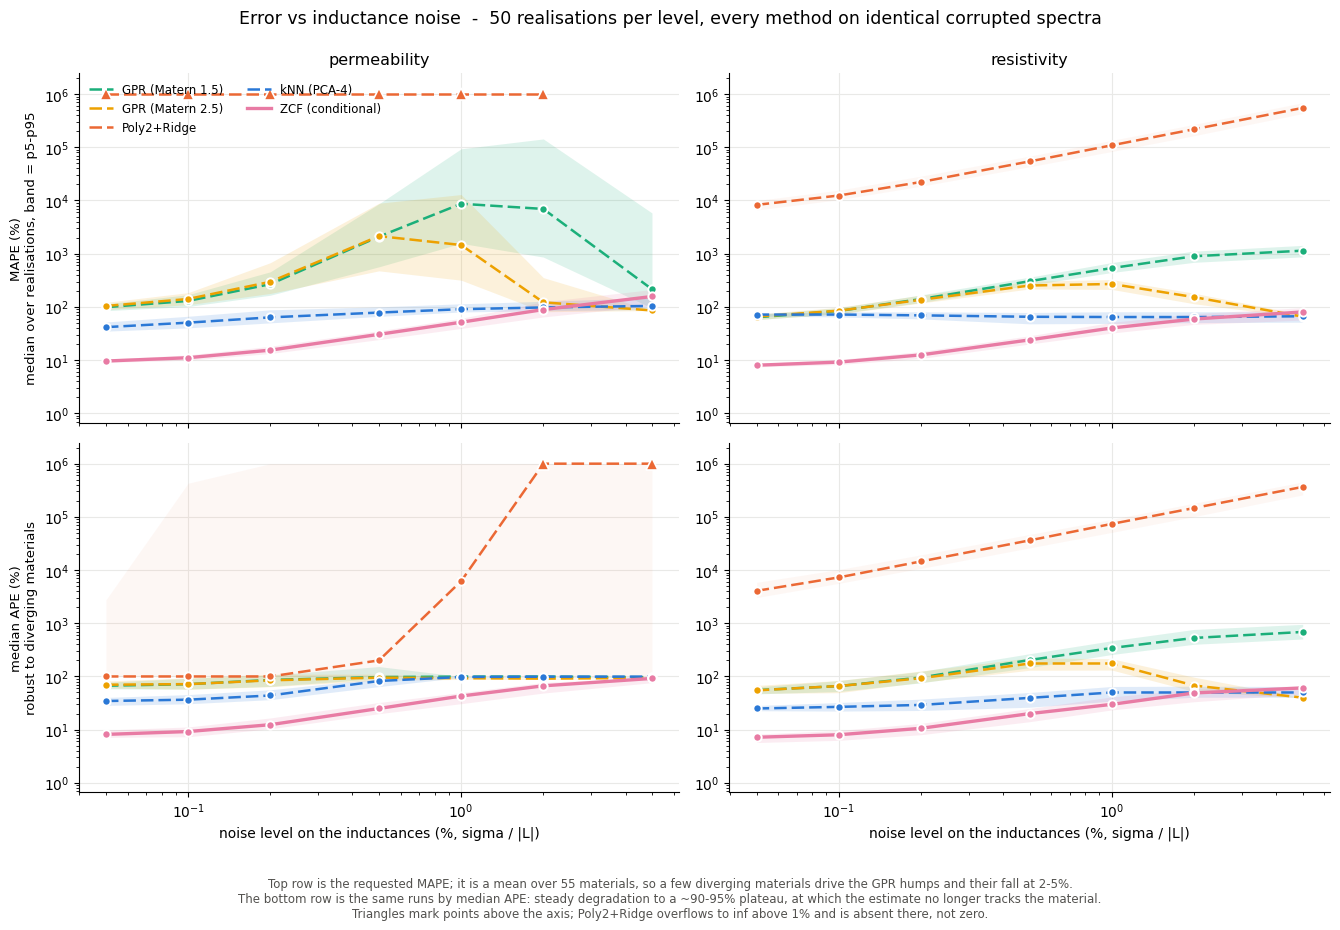

In [31]:
PALETTE = {'kNN (PCA-4)':      '#2a78d6',
           'Poly2+Ridge':      '#eb6834',
           'GPR (Matern 1.5)': '#1baf7a',
           'GPR (Matern 2.5)': '#eda100',
           'ZCF (conditional)':'#e87ba4'}

# Poly2+Ridge's median over realisations reaches ~1e301 (MAPE) and ~1e75 (median APE)
# before it overflows entirely; letting the log axis autoscale to that would compress
# every other series into a single line (and matplotlib overflows generating the ticks).
# Clipped to a readable window, with off-scale points marked.
FLOOR, CEIL = 1.0, 1e6

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2), sharex=True)

for row, (col_name, row_label) in enumerate([
        ('mape',       'MAPE (%)\nmedian over realisations, band = p5-p95'),
        ('median_ape', 'median APE (%)\nrobust to diverging materials')]):
    for ax, target in zip(axes[row], ['permeability', 'resistivity']):
        a = agg(target, col_name)
        for name in ORDER:
            s = a[a.method == name].sort_values('level')
            med = s['median'].to_numpy()
            ok  = np.isfinite(med)
            x   = (s.level * 100).to_numpy()
            is_zcf, col = name.startswith('ZCF'), PALETTE[name]

            # Poly2+Ridge's spread covers the whole panel (1e2-1e6) and would wash out
            # every other series, so its band is drawn faint. The line still carries it.
            lo_b = np.clip(np.nan_to_num(s.p5.to_numpy(), nan=FLOOR), FLOOR, CEIL)
            hi_b = np.clip(np.nan_to_num(s.p95.to_numpy(), nan=FLOOR), FLOOR, CEIL)
            ax.fill_between(x[ok], lo_b[ok], hi_b[ok], color=col, lw=0, zorder=1,
                            alpha=0.05 if name == 'Poly2+Ridge' else 0.14)

            y = np.clip(med, FLOOR, CEIL)
            ax.plot(x[ok], y[ok], lw=2.4 if is_zcf else 1.8, color=col,
                    ls='-' if is_zcf else (0, (5, 2)), zorder=3 if is_zcf else 2, label=name)
            inside = ok & (med <= CEIL)
            above  = ok & (med >  CEIL)
            ax.plot(x[inside], y[inside], 'o', ms=6, color=col, mec='white', mew=1.4, zorder=4)
            ax.plot(x[above], np.full(above.sum(), CEIL), '^', ms=9, color=col,
                    mec='white', mew=1.2, zorder=5)

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_ylim(FLOOR / 1.5, CEIL * 2.5)
        ax.grid(True, which='major', color='#e9e9e7', lw=0.8); ax.set_axisbelow(True)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
        if row == 0:
            ax.set_title(target, fontsize=11.5)
        else:
            ax.set_xlabel('noise level on the inductances (%, sigma / |L|)')
    axes[row][0].set_ylabel(row_label, fontsize=9.5)

axes[0][0].legend(frameon=False, fontsize=8.5, loc='upper left', ncol=2)
fig.suptitle(f'Error vs inductance noise  -  {len(SEEDS)} realisations per level, '
             'every method on identical corrupted spectra', fontsize=12.5, y=0.995)
fig.tight_layout(rect=(0, 0.075, 1, 1))
fig.text(0.5, 0.005,
         'Top row is the requested MAPE; it is a mean over 55 materials, so a few diverging '
         'materials drive the GPR humps and their fall at 2-5%.\nThe bottom row is the same '
         'runs by median APE: steady degradation to a ~90-95% plateau, at which the estimate '
         'no longer tracks the material.\nTriangles mark points above the axis; Poly2+Ridge '
         'overflows to inf above 1% and is absent there, not zero.',
         ha='center', va='bottom', fontsize=8.5, color='#52514e')
fig.savefig(fig_dir / 'noise_mape_vs_level.png', dpi=160, bbox_inches='tight')
plt.show()

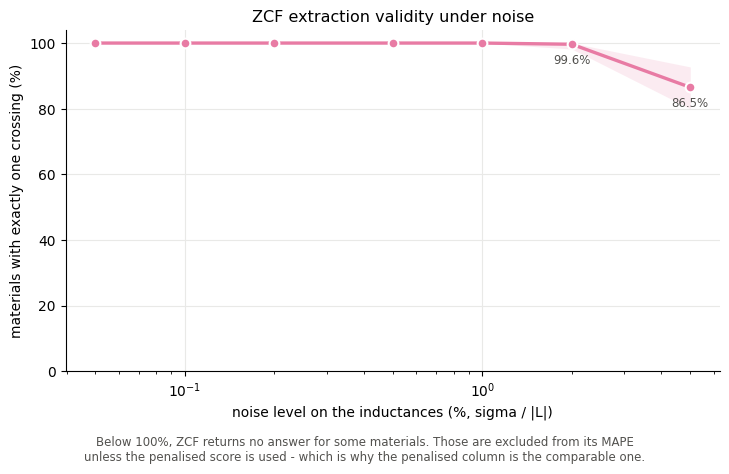

In [32]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
v = (RES[(RES.method == 'ZCF (conditional)') & (RES.target == 'permeability')]
     .groupby('level')['valid_rate'])
m, lo_q, hi_q = v.mean() * 100, v.quantile(0.05) * 100, v.quantile(0.95) * 100
x = m.index * 100

ax.fill_between(x, lo_q, hi_q, color=PALETTE['ZCF (conditional)'], alpha=0.15, lw=0)
ax.plot(x, m, lw=2.4, color=PALETTE['ZCF (conditional)'], marker='o', ms=7,
        mec='white', mew=1.5)
for xi, yi in zip(x, m):
    if yi < 99.9:
        ax.annotate(f'{yi:.1f}%', (xi, yi), xytext=(0, -14), textcoords='offset points',
                    ha='center', fontsize=8.5, color='#52514e')

ax.set_xscale('log'); ax.set_xlabel('noise level on the inductances (%, sigma / |L|)')
ax.set_ylabel('materials with exactly one crossing (%)')
ax.set_title('ZCF extraction validity under noise', fontsize=11.5)
ax.set_ylim(0, 104); ax.grid(True, color='#e9e9e7', lw=0.8); ax.set_axisbelow(True)
for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
fig.text(0.5, -0.06, 'Below 100%, ZCF returns no answer for some materials. Those are '
                     'excluded from its MAPE\nunless the penalised score is used - which is '
                     'why the penalised column is the comparable one.',
         ha='center', fontsize=8.5, color='#52514e')
fig.tight_layout()
fig.savefig(fig_dir / 'noise_zcf_valid_rate.png', dpi=160, bbox_inches='tight')
plt.show()

## Verdict

Both methods were given identical corrupted spectra, at seven levels, over 50 recorded
realisations each, with the noise placed on the inductances as specified.

**ZCF degrades smoothly and predictably.** Permeability runs 9.7% → 155% and resistivity
8.0% → 77% across the 0.05–5% range, monotone throughout, with a tight spread across
realisations (±0.5 pp at the low end, ±35 pp at the high).

**The dense models start from the transfer gap and degrade into a plateau.** The three
well-behaved models begin at 36–95% before any noise — the FE transfer failure, not a noise
effect — and their median APE climbs to a plateau near 90–95%, at which point the estimate
has stopped tracking the material. (Poly2+Ridge begins far higher, at ~2.9×10⁸%, and
diverges outright, overflowing to `inf` in 5/50 realisations at 1% and 50/50 at 5%.)

**The dense models have two independent problems, not one.** It would be easy to read
section 4 as saying noise is not their binding constraint — their FE curves barely move
until the noise is large. Section 6 shows that reading is wrong. Measured as pure
sensitivity, with accuracy cancelled out, **0.1% noise on the inductances already moves the
permeability estimate by ~37%, and it does so just as much on dense spectra as on FE.**
The flat curves were the transfer error hiding the noise error, not robustness.

So: the transfer gap is the thing to fix *first*, because it dominates the absolute
numbers — but fixing it alone would leave a model that is still unusable at any realistic
instrument noise. Both have to be addressed, and they are the same underlying illness:
the differential is ill-conditioned as an inversion target, so small input displacements
become large output ones.

Four qualifications hold that comparison in place:

0. **MAPE here is outlier-dominated and non-monotone; the median is the honest curve.**
   The GPR MAPE humps at 0.5–1% and its fall at 2–5% are a handful of diverging materials
   entering and then leaving the average as everything collapses to the plateau. Reporting
   only the mean would suggest noise *helps* above 2%, which it does not.

1. **ZCF is scored conditionally** — given the true value of the other property. The dense
   models are not. Its absolute advantage is overstated by an unknown amount.
2. **The valid-rate column is part of its score.** Where it drops, the valid-only MAPE is
   computed over easier survivors; the penalised column is the like-for-like one.
3. **One noise level on L is not one noise level in ΔL.** At a 1% level on L the effective
   relative noise spans 1.6% to 304% across the 16 channels — a 185× spread — so these
   curves are specific to this noise model, σ proportional to the coil modulus. Note what
   that does *not* imply: because |L| varies little across the band, σ_H is already within
   1.58× of a flat absolute floor, so swapping to one would change the channel loading only
   modestly. What is genuinely untested is structurally different noise — correlated across
   frequency, or slow drift — not the proportional-versus-flat distinction.

One thing this notebook does **not** establish: *why* the dense models plateau. Prior-mean
reversion is the plausible mechanism, but no cell here extracts the fitted kernel or the GP
prior, so the plateau is reported as an observation only. The section-6 sensitivity figures
rest on 12 seeds per level rather than the 50 used in section 4.

`results/noise_study.csv` holds every realisation (level, seed, method, target, mape,
median_ape, mape_penalised, valid_rate) so any of these aggregates can be recomputed and
the seeds are on record.